# Milestone 3 solution: Design a machine learning model for safety event frequency
 
## Objective
 
 - Build a machine learning model to predict the frequency (number) of different safety events in San-Francisco on a given date and in a particular neighborhood.
 
## Requirements
 - Note: this notebook requires scikit-learn 0.23.0+
 

In [1]:
# this plugin requires to run "pip install nb-black"
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

<IPython.core.display.Javascript object>

In [3]:
df = pd.read_parquet("../data/safety-SanFrancisco-2.parquet")

<IPython.core.display.Javascript object>

In [4]:
df.head()

,requestId,dataSubtype,dateTime,category,subcategory,status,address,latitude,longitude,source,neighborhood
0,1,911_Fire,2018-10-02 11:54:01,Potentially Life-Threatening,Medical Incident,None,ELM ST/FRANKLIN ST,37.781286,-122.422187,NaN,Tenderloin
1,2,311_All,2018-07-08 15:00:27,Street and Sidewalk Cleaning,Bulky Items,Closed,"1536 SACRAMENTO ST, SAN FRANCISCO, CA, 94109",37.791887,-122.418188,Mobile/Open311,Nob Hill
2,3,311_All,2016-06-28 13:12:28,General Request - COUNTY CLERK,customer_callback,Closed,Not associated with a specific address,0.000000,0.000000,Phone,None
3,7,311_All,2017-03-03 09:34:49,Temporary Sign Request,Temporary Sign Request for Other_Event_Type,Closed,"2190 NORTH POINT ST, SAN FRANCISCO, CA, 94123",37.802853,-122.443245,Phone,Marina
4,10,911_Fire,2016-10-25 18:33:20,Potentially Life-Threatening,Medical Incident,None,200 Block of DALEWOOD WAY,37.737953,-122.456498,NaN,Portola


<IPython.core.display.Javascript object>

## 1. Compute the aggregated dataset

Fist we filter the dataset to 2016-2019, the "Potentially Life-Threatening" category and 5 neighborhoods with most events,

In [5]:
top_neighborhood = df["neighborhood"].value_counts().head(5).index

mask = (
    df["dateTime"].dt.year.isin([2016, 2017, 2018, 2019])
    & (df["category"] == "Potentially Life-Threatening")
    & df["neighborhood"].isin(top_neighborhood)
)
df[mask].shape

(307034, 11)

<IPython.core.display.Javascript object>

then we compute the number of events for each 4 hour window and in each neigborhood:

**Note:** for categorical dtype it's important to pass `observed=True` to `groupby` to avoid to have entries for non present categories (which will make the computations slower and use more memory)

In [6]:
df_agg = (
    df[mask]
    .groupby(
        [pd.Grouper(key="dateTime", freq="6h"), "neighborhood"],
        observed=True,
    )["requestId"]
    .count()
    .reset_index()
    .rename(columns={"requestId": "count"})
)

<IPython.core.display.Javascript object>

In [7]:
df_agg.head(7)

,dateTime,neighborhood,count
0,2016-01-01 00:00:00,Ingleside,7
1,2016-01-01 00:00:00,Mission,22
2,2016-01-01 00:00:00,Nob Hill,13
3,2016-01-01 00:00:00,SoMa,33
4,2016-01-01 00:00:00,Tenderloin,36
5,2016-01-01 06:00:00,Mission,5
6,2016-01-01 06:00:00,Nob Hill,10


<IPython.core.display.Javascript object>

In [8]:
df_agg.shape

(27733, 3)

<IPython.core.display.Javascript object>

## 2. Perform a train / test split on this data

The data is first sorted by date, and then we perform a train / test split without shuffling,

In [9]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df_agg.sort_values("dateTime"), test_size=0.15, shuffle=False
)

<IPython.core.display.Javascript object>

In [10]:
df_train.shape, df_test.shape

((23573, 3), (4160, 3))

<IPython.core.display.Javascript object>

In [11]:
print("Train:", df_train["dateTime"].min(), "-", df_train["dateTime"].max())
print("Test:", df_test["dateTime"].min(), "-", df_test["dateTime"].max())

Train: 2016-01-01 00:00:00 - 2019-05-27 12:00:00
Test: 2019-05-27 12:00:00 - 2019-12-31 18:00:00


<IPython.core.display.Javascript object>

## 3. Extract features from the data

We define a function that would create new columns in the dataframe from the date and time,

In [12]:
def encode_timestamp(df):
    df = df.copy()
    for key in ["year", "month", "day", "dayofweek", "hour", "dayofyear"]:
        df[key] = getattr(df["dateTime"].dt, key)
    return df

<IPython.core.display.Javascript object>

In [13]:
encode_timestamp(df_train).tail()

,dateTime,neighborhood,count,year,month,day,dayofweek,hour,dayofyear
23568,2019-05-27 06:00:00,Mission,5,2019,5,27,0,6,147
23569,2019-05-27 06:00:00,Nob Hill,6,2019,5,27,0,6,147
23570,2019-05-27 06:00:00,SoMa,25,2019,5,27,0,6,147
23571,2019-05-27 06:00:00,Tenderloin,6,2019,5,27,0,6,147
23576,2019-05-27 12:00:00,Tenderloin,13,2019,5,27,0,12,147


<IPython.core.display.Javascript object>

Next we create a [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) estimator that would,
 - encode categorical variables with one hot encoding, since we will use a linear model first. For other ML models, this transformation might need adjustment. We consider the month, day etc as categorical variables to better model periodicity in the data.
 - Keep year a numerical variable to be able to extrapolate after 2019, with StandardScaler applied to make its scale comparable to the output of OneHotEncoding.
 
Finally we make a scikit-learn pipeline with,
 - `encode_timestamp` function wrapped with `FunctionTransformer` to make it a scikit-learn estimator that can be used in a pipeline
 - the above ColumnTransformer estimator 
 
and compute the transformed `X_train` and `X_test`.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
import sklearn

sklearn.set_config(display="diagram")

column_transformer_ohe = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(),
            ["neighborhood", "month", "day", "dayofweek", "hour", "dayofyear"],
        ),
        # we cannot one hot encode the year, as otherwise we won't
        # be able to extrapolate to later times.
        ("numeric", StandardScaler(), ["year"]),
    ]
)

pipe = make_pipeline(FunctionTransformer(encode_timestamp), column_transformer_ohe)
X_train = pipe.fit_transform(df_train)
X_test = pipe.transform(df_test)
pipe

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function encode_timestamp at 0x7f19685da940>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['neighborhood', 'month',
                                                   'day', 'dayofweek', 'hour',
                                                   'dayofyear']),
                                                 ('numeric', StandardScaler(),
                                                  ['year'])]))])

<IPython.core.display.Javascript object>

In [15]:
X_train.shape, X_test.shape

((23573, 426), (4160, 426))

<IPython.core.display.Javascript object>

## 4. Train a simple linear model and evaluate the results

We start by using [Ridge model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) which corresponds to a least squares linear regression with L2 penalty. 


**Note**: In machine learning would almost never use unpenalized linear regression, as the added penalty helps making the model robust in the case of colinear input features. 

In [16]:
from sklearn.linear_model import Ridge

est_lin = Ridge().fit(X_train, df_train["count"])

<IPython.core.display.Javascript object>

We can can compare the predictions with true values on a few examples,

In [17]:
df_viz = df_test.copy()

df_viz["count_pred"] = est_lin.predict(X_test).round(2)
df_viz.tail()

,dateTime,neighborhood,count,count_pred
27731,2019-12-31 18:00:00,SoMa,15,15.34
27728,2019-12-31 18:00:00,Ingleside,7,5.76
27729,2019-12-31 18:00:00,Mission,6,8.95
27730,2019-12-31 18:00:00,Nob Hill,17,9.38
27732,2019-12-31 18:00:00,Tenderloin,35,15.56


<IPython.core.display.Javascript object>

There is clearly correlation between predictions and true target variable but predictions are not very close either. Let's compute the Root Mean Squared Error (RMSE) on the train set,

In [18]:
from sklearn.metrics import mean_squared_error

y_pred = est_lin.predict(X_test)
score = mean_squared_error(df_test["count"], y_pred, squared=False)
print(score)

6.4152999161987765


<IPython.core.display.Javascript object>

We have an RMSE of 1.8 which can be put into perspective by computing the mean and the standard deviation of the target variable

In [19]:
print(f'mean={df_train["count"].mean()}, std={df_test["count"].std()}')

mean=10.894667628218725, std=8.279808870981375


<IPython.core.display.Javascript object>

The RMSE is smaller than the standard deviation but not by much. We can also compute evaluation metrics on the train and test sets a bit more systematically with a for loop,

In [20]:
from sklearn.metrics import mean_squared_error, max_error


def evaluate_model(est, labels, X_list, df_list):
    """Evaluate an ML model"""
    out = []
    for label, X, df_eval in zip(labels, X_list, df_list):
        y_pred = est.predict(X)
        score = mean_squared_error(df_eval["count"], y_pred, squared=False)
        out.append({"label": label, "metric": "RMSE", "score": score})
        score = max_error(df_eval["count"], y_pred)
        out.append({"label": label, "metric": "max error", "score": score})
    return (
        pd.DataFrame(out).set_index(["label", "metric"])["score"].unstack(-1).round(2)
    )


evaluate_model(est_lin, ["train", "test"], [X_train, X_test], [df_train, df_test])

metric,RMSE,max error
label,,
test,6.42,43.65
train,5.64,42.78


<IPython.core.display.Javascript object>

The error is comparable on the test and train set so the issue appears to be that we are underfitting. It's interesting to compare these results with that of the DummyRegression baseline,

In [21]:
from sklearn.dummy import DummyRegressor

est_dummy = DummyRegressor(strategy="mean")
est_dummy.fit(X_train, df_train["count"])

evaluate_model(est_dummy, ["train", "test"], [X_train, X_test], [df_train, df_test])

metric,RMSE,max error
label,,
test,8.36,52.11
train,7.36,56.11


<IPython.core.display.Javascript object>

Again, the liner model performs better that this baseline but not excessively.

Another aspect worth exploring is to compare the distribution of the predicted target variable as compared to the true target variable,

Text(0, 0.5, 'Density')

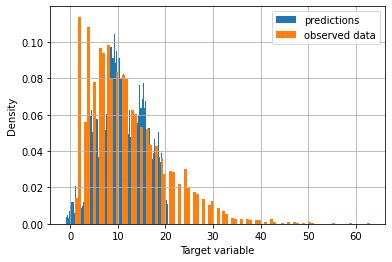

<IPython.core.display.Javascript object>

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

_ = ax.hist(est_lin.predict(X_test), bins=100, label="predictions", density=True)
df_test["count"].hist(bins=100, label="observed data", density=True)
ax.legend()
ax.set_xlabel("Target variable")
ax.set_ylabel("Density")

We observe that although there are some samples with more than 7 observed events, such values never happen in predictions. This indicates that either the frequency of events in each time interval has some random component that we are not able to predict (which is likely true), that some latent variables that would be able to explain these results are not present in the data, or that our model is significantly underfitting.

The same could be observed by plotting a 2D histogram of predicted vs observed values,

Text(0, 0.5, 'True value')

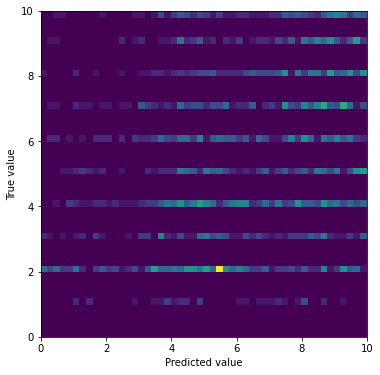

<IPython.core.display.Javascript object>

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.hist2d(
    est_lin.predict(X_test), df_test["count"].values, range=[[0, 10], [0, 10]], bins=50
)
ax.set_aspect("equal")
ax.set_xlabel("Predicted value")
ax.set_ylabel("True value")

## 5. Gradient boosting model

Gradient boosting decision trees (GBDT) is accurate and effective off-the-shelf algorithm for regression or classification that works well that is suitable to tabular data. Here we will use the histogram based variation included in scikit-learn (`HistGradientBoostingRegressor`) that is inspired by [LightGBM](https://lightgbm.readthedocs.io/en/latest/).

We re-create similar preprocessing pipeline to that of step 2 except for using OrdinalEncoder instead of OneHotEncoder, as tree based models are not suitable for very high dimensional features.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer


sklearn.set_config(display="diagram")

column_transformer_ord = ColumnTransformer(
    [
        (
            "cat",
            OrdinalEncoder(),
            ["neighborhood", "year"],
        ),
        (
            "passthrough",
            "passthrough",
            ["month", "day", "dayofweek", "hour", "dayofyear"],
        ),
    ]
)

pipe = make_pipeline(FunctionTransformer(encode_timestamp), column_transformer_ord)
X_train = pipe.fit_transform(df_train)
X_test = pipe.transform(df_test)

<IPython.core.display.Javascript object>

In [25]:
from sklearn.experimental import enable_hist_gradient_boosting  # noqa

from sklearn.ensemble import HistGradientBoostingRegressor

est_gb = HistGradientBoostingRegressor(max_iter=40, random_state=0).fit(
    X_train, df_train["count"]
)

<IPython.core.display.Javascript object>

In [26]:
df_viz = df_test.copy()

df_viz["count_pred"] = est_gb.predict(X_test).round(2)
df_viz.tail()

,dateTime,neighborhood,count,count_pred
27731,2019-12-31 18:00:00,SoMa,15,15.15
27728,2019-12-31 18:00:00,Ingleside,7,6.49
27729,2019-12-31 18:00:00,Mission,6,9.67
27730,2019-12-31 18:00:00,Nob Hill,17,9.73
27732,2019-12-31 18:00:00,Tenderloin,35,16.11


<IPython.core.display.Javascript object>

In [27]:
evaluate_model(est_gb, ["train", "test"], [X_train, X_test], [df_train, df_test])

metric,RMSE,max error
label,,
test,6.13,41.66
train,5.33,34.15


<IPython.core.display.Javascript object>

In [28]:
pipe

Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function encode_timestamp at 0x7f19685da940>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('cat', OrdinalEncoder(),
                                                  ['neighborhood', 'year']),
                                                 ('passthrough', 'passthrough',
                                                  ['month', 'day', 'dayofweek',
                                                   'hour', 'dayofyear'])]))])

<IPython.core.display.Javascript object>

To more reliably evaluate the model performance we can also compute these metrics with time based cross-validation,

**Note:** here we use `neg_root_mean_squared_error` because [scikit-learn scorers](https://scikit-learn.org/stable/modules/model_evaluation.html#common-cases-predefined-values) have the convention that higher scores are better (hence the negative sign)

In [29]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

cv = TimeSeriesSplit(n_splits=5)
-cross_val_score(
    est_gb, X_train, df_train["count"], cv=cv, scoring="neg_root_mean_squared_error"
)

array([5.81181044, 5.69499539, 5.43405248, 5.4139196 , 5.35286097])

<IPython.core.display.Javascript object>

(0.0, 15.0)

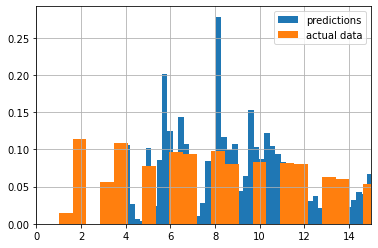

<IPython.core.display.Javascript object>

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

_ = ax.hist(est_gb.predict(X_test), bins=100, label="predictions", density=True)
df_test["count"].hist(bins=100, label="actual data", density=True)
ax.legend()
ax.set_xlim(0, 15)

Generally the predictions are better than with the linear model but can still likely be improved. We will evaluated possible approaches for improving this model in the following milestone. 